## Simulating the 2D Time-Dependent Schrödinger Equation (TDSE)

#### Rafał Głodek, Antoni Krzak, Michał Sapijaszko

---

### **I Physical and mathematical foundations**

#### **The governing equation**
We will be numerically integrating the 2D TDSE:

$$
i\hbar \frac{\partial \psi(x,y,t)}{\partial t} = \left( -\frac{\hbar^2}{2m} \nabla^2 + V(x,y) \right) \psi(x,y,t)
$$.

To simplify our computational model, we will use natural units (where $\hbar = 1$ and $m = 1$), reducing the constants and avoiding floating-point errors.

#### **The initial state**
The particle will be represented by a 2D Gaussian wave packet with an initial momentum $k_0$ in the $y$-direction:
$$
\psi(x,y,0) = A \exp\left(-\frac{(x-x_0)^2 + (y-y_0)^2}{2\sigma^2} + i k_0 y\right)
$$

#### **The potential landscapes ($V(x,y)$)**
* Double-slit: An infinitely high potential barrier spanning the $x$-axis, interrupted by two narrow gaps (regions where $V = 0$).
* Tunneling barrier: A finite rectangular potential barrier of height $V_0$ and thickness $d$. Crucially, we will set the packet's kinetic energy $E$ such that $E < V_0$ to observe the purely quantum mechanical "leakage."

### **II Numerical methodology**

#### Crank-Nicolson method (finite difference):
* Pros: Unconditionally stable, preserves total probability (unitarity).
* Cons: Requires solving a massive system of linear equations at each time step. In 2D, this becomes computationally expensive very quickly, even with sparse matrices.

#### Split-Operator Fourier Transform (SOFT) method:
* Pros: Exceptionally fast. It splits the Hamiltonian into kinetic and potential operators. The kinetic part is solved trivially in momentum space using the Fast Fourier Transform (FFT), while the potential part is solved in real space.
* Cons: Conditionally stable (requires careful tuning of the time step $\Delta t$ relative to the spatial grid $\Delta x$).
* Our Choice: We will use the SOFT Method. It is the industry standard for propagating 2D wave packets because Python's scipy.fft module is highly optimized.

### **III Code architecture**

1. Grid: A class to initialize the 2D spatial domain ($x$ and $y$ arrays) and the reciprocal momentum space grids ($k_x$ and $k_y$).
2. Potentials: Functions to generate 2D arrays representing our different scenarios (walls, slits, and finite barriers).
3. WavePacket: A class to initialize the Gaussian wave function and manage its state array.
4. Propagator: The core physics engine. A function that takes the current $\psi$, applies the half-step potential operator, performs an FFT, applies the kinetic operator, performs an inverse FFT, and applies the final half-step potential operator.

### **IV Visualization and analysis**
Since our primary goal includes smooth animations of complex phenomena, the visualization layer is just as critical as the physics engine.
1. Probability Density: The simulation outputs complex numbers. We will visualize the probability density, which is the absolute square of the wave function: $P(x,y,t) = |\psi(x,y,t)|^2$.
2. Animation Engine: We will use matplotlib.animation.FuncAnimation to iteratively call our propagator and update an imshow plot. We will use a perceptually uniform colormap (like viridis or magma) to accurately represent the intensity of the wave.
3. Tunneling Metrics: For the tunneling scenario, we will add an integration function to calculate the total probability of finding the particle on the "far side" of the barrier as time progresses, proving that transmission occurred.

---

## I. Theoretical background (Michał Sapijaszko) (PRZERZUĆCIE TO GDZIE UWAŻACIE ZA STOSOWNE XD)

### 1. Wave–particle duality:

Classical physics offers two disjoint vocabularies: *particles*, described by a position and a momentum, and obeying Newton's equations, and *waves*, described by a field obeying a linear wave equation and capable of interference. However, the experiments of the early twentieth century brought these two together. Light, long modelled as an electromagnetic wave, was shown by Einstein to be absorbed and emitted in discrete quanta of energy $E = h\nu = \hbar\omega$ [5]; conversely, de Broglie proposed that a particle of momentum $p$ carries a wavelength $\lambda = h/p$, i.e. $p = \hbar k$ [6], a prediction confirmed when Davisson and Germer diffracted electrons off a nickel crystal [8]. Neither object is purely a particle or purely a wave.

No other experiment proves this as conclusively as the **double-slit experiment** [4]. Particles fired one at a time through two slits arrive at the screen as individual, localized detections — yet the *distribution* of those detections, accumulated over many particles, is an interference pattern: alternating high- and low-probability fringes that cannot be reproduced by adding two independent single-slit distributions. The interference is therefore a property of the *probability* of arrival, not of any classical trajectory. To describe it we need an object that 
- is wave-like and superposable, so that contributions can interfere, and 
- yields a probability distribution for where the particle is found. 

### 2. The wave function and the Born rule

The state of the particle is a complex-valued function $\psi(\mathbf{r}, t) \in L^2(\mathbb{R}^2)$. It is not directly observable &mdash; its physical content is fixed by the **Born rule** [7], which interprets the squared modulus as a probability density on $\mathbb{R}^2$:

$$
dP = |\psi(\mathbf{r},t)|^2 \, d^2r, \qquad \int_{\mathbb{R}^2} |\psi(\mathbf{r},t)|^2 \, d^2r  = 1 .
$$

So $|\psi|^2$ is an ordinary probability density function and the normalization is simply the statement $\|\psi\|_{L^2} = 1$.

The essential point for what follows is that $\psi$ is **complex**: it carries an amplitude and a phase. Because the evolution law (next section) is linear, two contributions to the state add as complex numbers before the modulus is taken, $|\psi_1 + \psi_2|^2 = |\psi_1|^2 + |\psi_2|^2 + 2\,\mathrm{Re}(\psi_1^*\psi_2)$. The cross term is the interference term; where the two phases align it is positive (a bright fringe), where they oppose it is negative (a dark fringe). Interference is thus a direct consequence of linearity plus a complex state, and not an extra postulate [1].


### 3. The Schrödinger equation as the linear PDE

We need an evolution law for $\psi$. Rather than presenting the **time-dependent Schrödinger equation (TDSE)** as a postulate to be accepted, we can characterize it in a way familiar from the theory of linear PDEs: *it is the simplest linear, first-order-in-time equation whose plane-wave solutions reproduce the quantum dispersion relation* [1, 2].

Take the plane-wave ansatz $\psi = \exp[\,i(\mathbf{k}\cdot\mathbf{r} - \omega t)\,]$. The two empirical inputs $p = \hbar k$ [6] and $E = \hbar\omega$ [5], combined with the non-relativistic energy-momentum relation $E = p^2/2m$, fix the dispersion relation.

$$
\omega(\mathbf{k}) = \frac{\hbar\, k^2}{2m}, \qquad k^2 = k_x^2 + k_y^2 .
$$

We want a constant-coefficient PDE solved by every such plane wave. Differentiating the ansatz once in time pulls down $-i\omega$, and the Laplacian pulls down $-k^2$; imposing $\hbar\omega = \hbar^2 k^2/2m$ on these gives

$$
i\hbar\,\frac{\partial \psi}{\partial t} = -\frac{\hbar^2}{2m}\,\nabla^2 \psi .
$$

Adding a position-dependent potential $V(\mathbf{r})$ to the classical energy, $E = p^2/2m + V$, promotes the right-hand side to the full Hamiltonian and yields the TDSE [1]:

$$
\boxed{\;
i\hbar\,\frac{\partial \psi}{\partial t}
= \hat H \psi
= \left( -\frac{\hbar^{2}}{2m}\,\nabla^{2} + V(\mathbf{r}) \right)\psi
\;}
$$

Two structural facts matter for both the physics and the numerics [2]. First, in Fourier space the operator $-i\nabla$ acts as multiplication by $\mathbf{k}$, so the kinetic term $\hat T = -\tfrac{\hbar^2}{2m}\nabla^2$ is diagonal there, while $V(\mathbf{r})$ is diagonal in real space, which is useful for numerical method we've chosen. Second, the evolution operator $U(t) = e^{-i\hat H t/\hbar}$ is unitary, which means that $\|\psi(t)\|_{L^2} = \|\psi(0)\|_{L^2}$ for all $t$. Finally, the equation is linear, so superpositions of solutions are solutions; this is the mathematical root of the interference described in section 2.

For our 2D problem $\nabla^2 = \partial_x^2 + \partial_y^2$ and $\psi = \psi(x,y,t)$. Following standard practice for wave-packet propagation [3] we use natural units $\hbar = 1,\ m = 1$, which removes the physical constants from the arithmetic and leaves us with the equation actually integrated by the code,

$$
i\,\frac{\partial \psi}{\partial t}
= \left( -\tfrac{1}{2}\nabla^{2} + V(x,y) \right)\psi,
\qquad \omega(\mathbf{k}) = \tfrac{1}{2}k^2 .
$$

### 4. Encoding the apparatus in the potential $V(x,y)$

All scenarios share the evolution law and differ only in $V(x,y)$, which plays the role of the apparatus:

- **Free propagation** ($V \equiv 0$): the baseline, a packet that merely drifts and disperses.
- **Double slit**: a wall across the packet's path with $V$ set numerically huge ($\sim 10^{6}$, an effectively impenetrable barrier), pierced by two narrow gaps where $V = 0$. Where $V \gg E$ the equation forces $\psi \approx 0$, so amplitude can only emerge through the slits; the two emerging beams overlap and interfere.
- **Tunneling barrier**: a finite rectangular region of height $V_0$ and thickness $d$, with the packet's energy deliberately chosen as $E < V_0$. Classically the particle is reflected with certainty; quantum-mechanically part of the amplitude crosses (section 6).

### References

**Textbooks (general background — duality, Schrödinger equation, wave packets, tunneling):**

1. D. J. Griffiths and D. F. Schroeter, *Introduction to Quantum Mechanics*, 3rd ed., Cambridge University Press, 2018. — Motivation of the TDSE (Ch. 1–2), free-particle wave packets and group velocity (§2.4), the finite barrier and tunneling (§2.6).
2. J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed., Cambridge University Press, 2021. — Operator formalism, the Hamiltonian as generator of time evolution, unitarity.
3. D. J. Tannor, *Introduction to Quantum Mechanics: A Time-Dependent Perspective*, University Science Books, 2007. — Wave-packet dynamics and the split-operator / Fourier propagation method used in this project.
4. R. P. Feynman, R. B. Leighton, and M. Sands, *The Feynman Lectures on Physics, Vol. III: Quantum Mechanics*, Ch. 1, Addison-Wesley, 1965. — The double-slit experiment as the central illustration of quantum behaviour. (Online: https://www.feynmanlectures.caltech.edu/III_01.html)

**Primary historical sources (wave–particle duality):**

5. A. Einstein, "Über einen die Erzeugung und Verwandlung des Lichtes betreffenden heuristischen Gesichtspunkt," *Annalen der Physik* **17** (1905) 132–148. DOI: 10.1002/andp.19053220607. — Light quanta (photons); $E=h\nu$.
6. L. de Broglie, *Recherches sur la théorie des quanta*, doctoral thesis, University of Paris, 1924. — Matter waves; $\lambda = h/p$.
7. M. Born, "Zur Quantenmechanik der Stoßvorgänge," *Zeitschrift für Physik* **37** (1926) 863–867. DOI: 10.1007/BF01397477. — The probabilistic (Born) interpretation of $|\psi|^2$.
8. C. Davisson and L. H. Germer, "Diffraction of Electrons by a Crystal of Nickel," *Physical Review* **30** (1927) 705–740. DOI: 10.1103/PhysRev.30.705. — Experimental confirmation of matter waves.

**Numerical method (SOFT / split-operator):**

9. M. D. Feit, J. A. Fleck Jr., and A. Steiger, "Solution of the Schrödinger equation by a spectral method," *Journal of Computational Physics* **47** (3) (1982) 412–433. DOI: 10.1016/0021-9991(82)90091-2. — The split-operator Fourier method for propagating the TDSE.
10. G. Strang, "On the Construction and Comparison of Difference Schemes," *SIAM Journal on Numerical Analysis* **5** (3) (1968) 506–517. DOI: 10.1137/0705041. — Second-order operator (Strang) splitting.

### Imports

In [1]:
import numpy as np
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

### Discretized grid

Our first step in the numerical solution of the Time-Dependent Schrödinger Equation is the implementation of the `Grid` class. It is responsible for creating the numerical space in which we solve our PDE. Since a computer cannot solve the equation directly on a continuous domain, we replace the physical space with a discrete approximation.

The class initializes two grids: a spatial grid and a momentum-space grid. The spatial grid is centered around the point $(0,0)$ and consists of `nx` $\times$ `ny` points, with spacings `dx` and `dy` in the respective directions. It is used to store the positions of physical objects in the simulation, such as the wave packets, barriers, and slits.

The second grid represents the corresponding Fourier-space coordinates. It is constructed using the frequencies associated with the Fast Fourier Transform and multiplied by $2\pi$ to obtain angular wave numbers. This grid is important for the Split-Operator Fourier Transform method used later, because the kinetic part of the Schrödinger equation is evaluated efficiently in momentum space.

In [2]:
class Grid:
    def __init__(self, nx, ny, dx, dy):
        """
        Initializes the 2D spatial and momentum grids.
        nx, ny: Number of grid points (should be powers of 2 for optimal FFT speed).
        dx, dy: Spatial step size.
        """
        self.nx, self.ny = nx, ny
        self.dx, self.dy = dx, dy

        # Real space grid (centered at 0,0)
        x = np.arange(-nx/2, nx/2) * dx
        y = np.arange(-ny/2, ny/2) * dy
        self.X, self.Y = np.meshgrid(x, y)

        # Momentum space grid (reciprocal space for FFT)
        kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
        ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
        self.KX, self.KY = np.meshgrid(kx, ky)

### Potentials

After defining the numerical grid, our next step is constructing the potential function `V(x,y)`. In the Schrödinger equation, this potential dictates how the wave packet interacts with its environment by mapping out obstacles like walls and slits, while regions of zero potential represent free space without any barriers. This landscape is generated using the `create_potential` function, which returns a two-dimensional array matching the spatial grid's size and offers a choice between *four* distinct simulation scenarios.

The first two scenarios (`"single_slit"` and `"double_slit"`) are grouped together as they both generate high-potential walls. In the single-slit case, the opening is placed precisely in the middle of the wall, whereas the double-slit setup places two openings at an equal distance from the center. Aside from these slits, the constructed wall is effectively impenetrable. We can also manipulate specific arguments of this potential, including its `wall_height` (`V0`), `wall_thickness`, `wall_y` (placement), and `slit_width`, as well as the `slit_separation` for the double-slit configuration.

Another option is the `"tunneling"` scenario. Instead of an almost infinite wall, this generates a finite barrier. Similarly to the slit scenarios, it features strictly adjustable parameters: `barrier_height` (`V0`), `barrier_thickness`, `barrier_width`, and `barrier_y`. This setup is used to study quantum tunneling, where a wave packet with a lower energy than the barrier potential may still have a nonzero probability of transmitting to the other side.

Finally, the function includes a `"free"` scenario, where no potential is applied, allowing the wave packet to evolve unobstructed. This serves as a useful baseline to verify how the packet naturally disperses without interacting with any obstacles. The resulting array `V` is later used by the propagator in the Split-Operator Fourier Transform method to advance the wave function in time.

In [3]:
def create_potential(grid, p_type="double_slit", V0=None, **params):
    """
    Generates V(x, y) for the simulation scenarios.

    Scenarios:
    - "double_slit" / "slit": hard wall with two open slits.
    - "single_slit": hard wall with one open slit.
    - "tunneling" / "barrier": finite rectangular barrier with E < V0.
    - "free": no obstacle, useful as a baseline.
    """
    V = np.zeros((grid.ny, grid.nx), dtype=float)
    scenario = p_type.lower()

    if scenario in ("double_slit", "slit", "single_slit"):
        wall_height = 1e6 if V0 is None else V0
        wall_thickness = params.get("wall_thickness", 0.6)
        slit_width = params.get("slit_width", 0.8)
        slit_separation = params.get("slit_separation", 3.0)
        wall_y = params.get("wall_y", 0.0)

        wall_mask = np.abs(grid.Y - wall_y) <= wall_thickness / 2
        V[wall_mask] = wall_height

        if scenario == "single_slit":
            open_mask = np.abs(grid.X) <= slit_width / 2
        else:
            upper_slit = np.abs(grid.X - slit_separation / 2) <= slit_width / 2
            lower_slit = np.abs(grid.X + slit_separation / 2) <= slit_width / 2
            open_mask = upper_slit | lower_slit

        V[wall_mask & open_mask] = 0.0

    elif scenario in ("tunneling", "tunneling_barrier", "barrier"):
        barrier_height = 2.4 if V0 is None else V0
        barrier_thickness = params.get("barrier_thickness", 1.0)
        barrier_width = params.get("barrier_width", 7.0)
        barrier_y = params.get("barrier_y", 0.0)
        barrier_mask = (
            (np.abs(grid.Y - barrier_y) <= barrier_thickness / 2) &
            (np.abs(grid.X) <= barrier_width / 2)
        )
        V[barrier_mask] = barrier_height

    elif scenario == "free":
        pass
    else:
        raise ValueError(f"Unknown potential scenario: {p_type}")

    return V

### Gaussian wave packet

The `initialize_wave_packet` function defines the initial state of the quantum particle. Since the Time-Dependent Schrödinger Equation describes the evolution of a wave function, we first need to specify the wave function at time $t = 0$. In this project, the initial state is chosen to be a two-dimensional Gaussian wave packet.

The Gaussian envelope determines where the particle is initially localized in space. Its center is given by the parameters `x0` and `y0`, while the parameter `sigma` controls the width of the packet. A smaller value of `sigma` produces a more localized packet, whereas a larger value creates a wider wave packet.

The function also includes a complex phase factor, `exp(1j * k0y * grid.Y)`. This phase gives the packet an initial momentum in the positive or negative $y$-direction, depending on the sign of `k0y`. In our simulations, this is what makes the packet move toward the barrier or slit system.

The normalization factor is included so that the total probability represented by the wave function is approximately equal to one. This is important because $|\psi(x,y,t)|^2$ is interpreted as the probability density of finding the particle at a given point.

Overall, this function prepares the initial quantum state before time evolution begins. The returned array is complex-valued and has the same shape as the spatial grid, so it can be directly passed to the propagator used later in the simulation.

In [4]:
def initialize_wave_packet(grid, x0, y0, k0y, sigma):
    """
    Creates the initial complex wave function psi(x,y,t=0).
    """
    # Normalization constant
    norm = 1.0 / (sigma * np.sqrt(np.pi))
    
    # Gaussian envelope (real part)
    envelope = np.exp(-((grid.X - x0)**2 + (grid.Y - y0)**2) / (2 * sigma**2))
    
    # Phase factor determining momentum (complex part)
    phase = np.exp(1j * k0y * grid.Y)
    
    return norm * envelope * phase

### SOFT

The core numerical method used in this project is the Split-Operator Fourier Transform method, abbreviated as SOFT [9]. This method approximates the time evolution of the wave function governed by the Time-Dependent Schrödinger Equation. In our case, the equation is solved in two spatial dimensions for a quantum wave packet moving through different potential landscapes.

The Time-Dependent Schrödinger Equation can be written in the form

$$
i \frac{\partial \psi}{\partial t} = H\psi,
$$

where $\psi(x,y,t)$ is the complex-valued wave function and $H$ is the Hamiltonian operator. In our simulation, natural units are used, so $\hbar = 1$ and $m = 1$. The Hamiltonian is split into two parts:

$$
H = K + V.
$$

Here, $K$ is the kinetic energy operator and $V$ is the potential energy operator. The kinetic part contains spatial derivatives and is related to the Laplacian operator:

$$
K = -\frac{1}{2}\nabla^2.
$$

The potential part $V(x,y)$ describes the environment through which the wave packet moves. It represents barriers, walls, slits, or free space depending on the chosen scenario.

If the Hamiltonian were simple, the exact time evolution over a small time step $\Delta t$ could be written using the evolution operator

$$
\psi(t+\Delta t) = e^{-iH\Delta t}\psi(t).
$$

However, because $H = K + V$, this becomes

$$
\psi(t+\Delta t) = e^{-i(K+V)\Delta t}\psi(t).
$$

The difficulty is that the kinetic operator $K$ and the potential operator $V$ generally do not commute. This means that

$$
e^{-i(K+V)\Delta t} \neq e^{-iK\Delta t}e^{-iV\Delta t}.
$$

Therefore, we cannot simply apply the kinetic and potential effects independently without introducing an approximation. The Split-Operator method solves this problem by using a symmetric approximation called Strang splitting [10]:

$$
\psi(t+\Delta t)
\approx
e^{-iV\Delta t/2}
e^{-iK\Delta t}
e^{-iV\Delta t/2}
\psi(t).
$$

This means that each time step is divided into three parts. First, the wave function is evolved by half a time step under the influence of the potential. Then it is evolved by a full time step under the influence of the kinetic energy. Finally, another half time step of the potential evolution is applied. This symmetric structure is important because it gives better accuracy than simply applying the full potential step followed by the full kinetic step.

The reason this method is efficient is that the two parts of the Hamiltonian are simple in different representations. The potential operator is simple in real space. Since $V(x,y)$ is just a function defined at every grid point, applying the potential evolution means multiplying the wave function by a phase factor:

$$
e^{-iV(x,y)\Delta t/2}.
$$

This operation is local: each value of the wave function is multiplied independently at each point of the spatial grid.

However, the kinetic operator is not that simple in real space because it contains derivatives. Directly approximating those derivatives would require a finite-difference scheme. Instead, SOFT uses the Fourier transform. In momentum space, derivatives become multiplication by wave numbers. For a Fourier mode with wave numbers $k_x$ and $k_y$, the kinetic energy becomes

$$
K = \frac{k_x^2 + k_y^2}{2}.
$$

This is why the `Grid` class also creates the arrays `KX` and `KY`. They store the momentum-space coordinates corresponding to the spatial grid. Once the wave function is transformed into Fourier space using `fft2`, the kinetic evolution can be applied by simple multiplication:

$$
e^{-iK\Delta t}
=
e^{-i(k_x^2+k_y^2)\Delta t/2}.
$$

After this multiplication, the wave function is transformed back to real space using the inverse Fourier transform `ifft2`.

In the implementation, this full time step is performed inside the `step` method of the `Propagator` class. The code first multiplies the wave function by `V_half_step`, which corresponds to the first factor

$$
e^{-iV\Delta t/2}.
$$

Then the wave function is transformed into momentum space using `fft2`. In that representation, it is multiplied by `K_step`, which represents the kinetic evolution factor

$$
e^{-iK\Delta t}.
$$

After that, `ifft2` returns the wave function to real space. Finally, the second half-step of the potential evolution is applied by multiplying again by `V_half_step`.

The numerical sequence is therefore:

$$
\psi(x,y)
\rightarrow
e^{-iV\Delta t/2}\psi(x,y)
\rightarrow
\mathcal{F}[\psi]
\rightarrow
e^{-iK\Delta t}\mathcal{F}[\psi]
\rightarrow
\mathcal{F}^{-1}[\psi]
\rightarrow
e^{-iV\Delta t/2}\psi(x,y).
$$

This procedure is repeated many times to simulate the full time evolution of the quantum system.

An important feature of the method is that, when no absorbing boundaries or hard-wall masks are applied, the split-operator evolution is approximately unitary. This means that the total probability of the wave function is preserved. Physically, this is important because the particle must exist somewhere in the domain, so the integral of $|\psi(x,y,t)|^2$ over all space should remain equal to one.

In our simulation, additional numerical treatments are also used. For hard-wall slit experiments, regions corresponding to impenetrable walls are masked so that the wave function is set to zero there. This represents the fact that the particle cannot exist inside an infinitely high potential barrier. The code also uses an absorbing rim near the edges of the grid. This is needed because FFT-based methods naturally assume periodic boundaries, meaning that a wave leaving one side of the grid could artificially reappear on the opposite side. The absorber reduces these unwanted reflections and wrap-around effects.

The SOFT method is especially well suited for this project because we simulate wave packets in two dimensions. A fully finite-difference implicit method such as Crank-Nicolson would require solving a large system of equations at every time step. In contrast, SOFT replaces the difficult derivative calculation with fast Fourier transforms, which are highly optimized in scientific Python libraries. As a result, the method is both accurate and computationally efficient for observing diffraction, interference, and tunneling.

In summary, the Split-Operator Fourier Transform method works by separating the Hamiltonian into potential and kinetic parts, applying each part in the representation where it is easiest to compute, and alternating between real space and momentum space using FFT. The potential effects are handled directly on the spatial grid, while the kinetic spreading of the wave packet is handled in Fourier space. Repeating this process over many small time steps gives the numerical time evolution of the wave function.

In [5]:
class Propagator:
    def __init__(self, grid, V, dt, hard_wall_mask=None, absorber_width=18, absorber_strength=0.015):
        """
        Initializes the split-operator evolution matrices.
        Optional masks make hard obstacles absorbing and reduce FFT wrap-around.
        """
        self.dt = dt
        self.hard_wall_mask = hard_wall_mask

        # Half-step potential operator. Natural units: hbar = 1, m = 1.
        self.V_half_step = np.exp(-0.5j * V * dt)

        # Full-step kinetic operator in momentum space: K = (kx^2 + ky^2) / 2m.
        K = (grid.KX**2 + grid.KY**2) / 2.0
        self.K_step = np.exp(-1j * K * dt)
        self.absorber = self._make_absorber(grid, absorber_width, absorber_strength)

    def _make_absorber(self, grid, width, strength):
        """Cosine-like absorbing rim to suppress periodic FFT boundary echoes."""
        if width <= 0 or strength <= 0:
            return np.ones((grid.ny, grid.nx))

        ix = np.minimum(np.arange(grid.nx), np.arange(grid.nx)[::-1])
        iy = np.minimum(np.arange(grid.ny), np.arange(grid.ny)[::-1])
        edge_distance = np.minimum.outer(iy, ix)
        rim = np.clip((width - edge_distance) / width, 0.0, 1.0)
        return np.exp(-strength * rim**2)

    def step(self, psi):
        """Propagates the wave function psi forward by one time step dt."""
        if self.hard_wall_mask is not None:
            psi[self.hard_wall_mask] = 0.0

        psi *= self.V_half_step
        psi_k = fft2(psi)
        psi_k *= self.K_step
        psi = ifft2(psi_k)
        psi *= self.V_half_step
        psi *= self.absorber

        if self.hard_wall_mask is not None:
            psi[self.hard_wall_mask] = 0.0

        return psi

### Quantum tunneling

In our simulation, tunneling is studied by using a finite rectangular potential barrier. After the wave packet evolves and interacts with this barrier, we calculate the probability that part of the wave function has reached the region beyond it. This quantity is called the transmission probability and is obtained by integrating the probability density $|\psi(x,y,t)|^2$ over the area behind the barrier:

$$
T(t) = \int_{-\infty}^{\infty} \int_{y_{\text{end}}}^{\infty} |\psi(x, y, t)|^2 \,dy\,dx
$$

Here, $y_{\text{end}}$ denotes the position beyond the barrier from which we start counting the transmitted part of the wave packet. In other words, the integral measures the total probability of finding the particle on the far side of the barrier.

Numerically, this integral is replaced by a sum over grid points. The function `calculate_transmission` selects all points for which `grid.Y > y_cut`, meaning points located on the other side of the barrier. It then sums the probability density in that region and multiplies the result by the area of one grid cell, `dx * dy`.

The resulting value represents the transmission probability. If the barrier were completely impenetrable, this probability would remain close to zero. For a finite quantum barrier, a nonzero value indicates that part of the wave packet has tunneled through the barrier.

In [6]:
def calculate_transmission(grid, psi, y_cut=0.5):
    """Probability of finding the particle beyond a chosen y cut."""
    far_side_mask = grid.Y > y_cut
    return np.sum(np.abs(psi[far_side_mask])**2) * grid.dx * grid.dy


def calculate_region_probability(grid, psi, mask):
    """Convenience integral of |psi|^2 over any boolean region mask."""
    return np.sum(np.abs(psi[mask])**2) * grid.dx * grid.dy

## Motivation: From Young's Experiment to Quantum Wave Packets

The double-slit experiment is one of the most important demonstrations of wave behavior in physics. Its significance comes from the fact that it reveals a phenomenon that cannot be explained by a purely classical particle picture: interference. In the context of this project, the experiment provides a natural bridge between classical wave physics and quantum mechanics. By simulating the time-dependent Schrödinger equation in two spatial dimensions, we aim to reproduce the essential features of Young-type experiments and visualize how a quantum wave packet evolves, diffracts, interferes, and tunnels through potential barriers.

At the beginning of the nineteenth century, the physical nature of light was still debated. One influential view, associated with Isaac Newton, treated light as a stream of small corpuscles travelling along well-defined paths. This interpretation was intuitively appealing because it could explain rectilinear propagation and reflection in a way similar to the motion of particles. In contrast, Christiaan Huygens proposed a wave theory of light, according to which light propagates through space as a disturbance. The wave interpretation was able to describe phenomena such as diffraction and interference, but for a long time Newton's particle-like view remained highly influential.

Thomas Young's interference experiment gave strong evidence in favor of the wave nature of light. In the idealized version of the experiment, a coherent beam of light illuminates a barrier containing two narrow openings. If light behaved only as a collection of classical particles passing independently through one slit or the other, one would expect two bright regions on a screen placed behind the barrier. Instead, the observed intensity distribution consists of alternating bright and dark fringes. These fringes are naturally explained by the superposition of waves emerging from the two slits. Where the waves arrive in phase, they reinforce each other and produce high intensity. Where they arrive out of phase, they cancel partially or almost completely, producing low intensity.

The importance of the double-slit experiment increased even further with the development of quantum mechanics. In classical optics, the interference pattern can be interpreted as the result of overlapping electromagnetic waves. In quantum mechanics, however, similar interference patterns appear even for particles with mass, such as electrons. This became conceptually possible after Louis de Broglie proposed that matter has wave-like properties. According to the de Broglie hypothesis, a particle with momentum (p) is associated with a wavelength

$$\lambda = \frac{h}{p},$$

where $h$ is Planck's constant. This idea was one of the foundations of wave mechanics and led to the description of particles by wavefunctions.

The quantum version of the double-slit experiment is especially striking when particles are sent toward the slits one at a time. Each individual particle is detected at a localized point on the screen, which reflects its particle-like aspect. However, after many such detections, the accumulated distribution forms an interference pattern. This means that the pattern is not produced by classical collisions between many particles. Instead, it arises from the wave-like evolution of the probability amplitude associated with each particle.

In the Schrödinger formulation of quantum mechanics, the state of a particle is represented by a complex-valued wavefunction $\psi(x,y,t)$. The wavefunction itself is not directly observed as a material wave. Rather, its squared modulus,

$$
|\psi(x,y,t)|^2,
$$

is interpreted as a probability density for detecting the particle near the point $(x,y)$ at time $t$. This probabilistic interpretation of $|\psi|^2$ is due to Born [7]; for it to be consistent, $\psi$ is a normalized element of $L^2(\mathbb{R}^2)$, $\int |\psi(x,y,t)|^2\,dx\,dy = \|\psi\|_{L^2}^2 = 1$. The wavefunction evolves according to the time-dependent Schrödinger equation, and because this equation is linear, different parts of the wavefunction can superpose and interfere. Concretely, two contributions add as complex numbers before the modulus is taken, $|\psi_1+\psi_2|^2 = |\psi_1|^2 + |\psi_2|^2 + 2\,\mathrm{Re}(\psi_1^*\psi_2)$, and the cross term is what produces the bright and dark fringes. This is the mathematical reason why the double-slit experiment can be reproduced by solving the Schrödinger equation.

The aim of our numerical experiment is therefore not merely to create an animation resembling a classical wave pattern. Instead, we simulate the evolution of a quantum wave packet governed by the two-dimensional time-dependent Schrödinger equation. The initial state is a localized Gaussian packet moving toward a potential barrier. By changing the structure of the potential, we reproduce several related scenarios: propagation through a single slit, propagation through a double slit, and tunnelling through a finite barrier. In each case, the simulation shows how the probability density evolves in time.

The single-slit case demonstrates diffraction: after passing through a narrow aperture, the wave packet spreads in the transverse direction. The double-slit case demonstrates interference: the parts of the wavefunction transmitted through the two openings overlap and create alternating regions of high and low probability density. The tunnelling case demonstrates another purely quantum effect: even when the particle energy is below the height of a finite barrier, a nonzero part of the wavefunction can appear on the other side.

Thus, Young's experiment serves as the conceptual starting point for the whole project. It shows why the wave description is necessary, while the Schrödinger equation provides the mathematical model that allows us to simulate this behavior. The numerical results presented later in the report illustrate how wave-particle duality emerges from the time evolution of the quantum state: the particle is detected probabilistically, but the probability distribution evolves, diffracts, interferes, and tunnels like a wave.


## Experimental Geometry and Numerical Reconstruction

After motivating the role of Young's experiment in the study of wave-particle duality, we now describe how this physical experiment is represented in our numerical model. The classical double-slit setup consists of a coherent source, an opaque barrier with two narrow openings, and a screen on which the interference pattern is observed. In our project, this idea is reconstructed using a two-dimensional solution of the time-dependent Schrödinger equation. The continuous optical wave is replaced by a quantum wave packet, and the screen intensity is replaced by the probability density associated with the wavefunction.

In the idealized Young geometry, a coherent source $S$ emits waves toward a barrier containing two openings, denoted by $S_1$ and $S_2$.

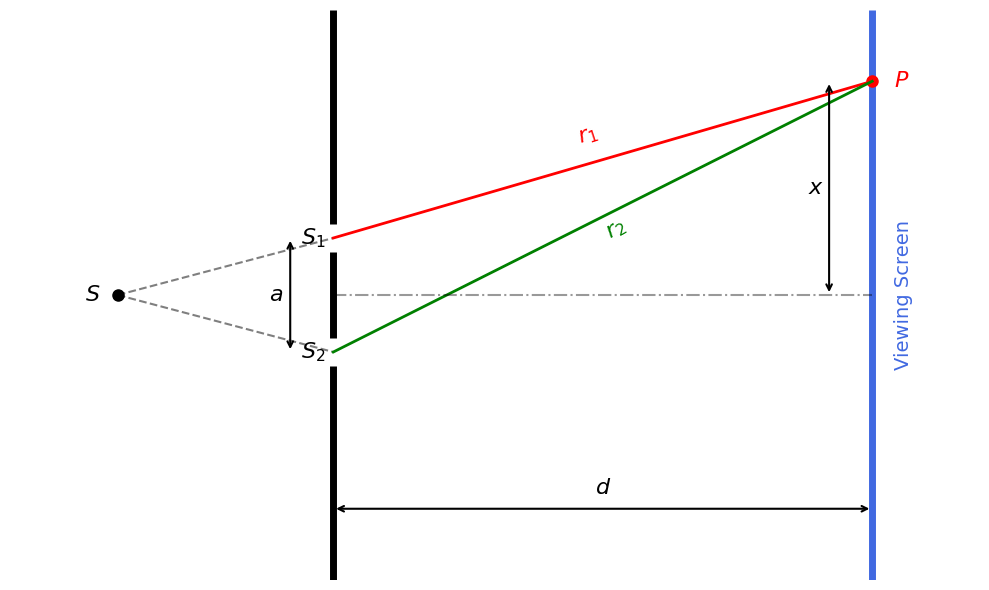

The distance between the centers of the two slits is denoted by $a$. A viewing screen is placed at a distance $d$ behind the barrier. At a given observation point $P$ on the screen, the waves arriving from the two slits have travelled different distances, denoted by $r_1$ and $r_2$. The essential quantity determining the observed interference pattern is the path length difference

$$
\Delta r = r_2-r_1.
$$

If the observation screen is far from the slits compared with the slit separation, that is, if $d \gg a$, the rays from the two slits to the point $P$ are approximately parallel. Under this far-field approximation, the path length difference can be written as

$$
\Delta r \approx a\sin\theta,
$$

where $\theta$ is the angle between the central axis and the line connecting the slit region to the observation point. For small angles, we may use

$$
\sin\theta \approx \tan\theta \approx \frac{x}{d},
$$

where $x$ is the transverse displacement of $P$ from the central axis. Therefore,

$$
\Delta r \approx a\frac{x}{d}.
$$

This relation explains why the screen does not simply show two bright regions corresponding to the two slits. Instead, the intensity depends on whether the two waves arrive in phase or out of phase.

Constructive interference occurs when the path length difference is an integer multiple of the wavelength:

$$
\Delta r = m\lambda,
\qquad m = 0,\pm 1,\pm 2,\ldots
$$

In this case, crests meet crests and troughs meet troughs, so the two contributions reinforce each other. The corresponding approximate positions of the bright fringes are

$$
x_m \approx \frac{m\lambda d}{a}.
$$

Destructive interference occurs when the path length difference is shifted by half a wavelength:

$$
\Delta r = \left(m+\frac{1}{2}\right)\lambda,
\qquad m = 0,\pm 1,\pm 2,\ldots
$$

Then the two waves arrive with opposite phase and partially cancel. The approximate positions of the dark fringes are therefore

$$
x_m \approx \frac{\left(m+\frac{1}{2}\right)\lambda d}{a}.
$$

The second schematic diagram illustrates how these mathematical conditions translate into an actual interference pattern. The waves emerging from $S_1$ and $S_2$ overlap in the region behind the barrier. In some places the two waves arrive in phase and create constructive interference, while in other places they arrive out of phase and create destructive interference.

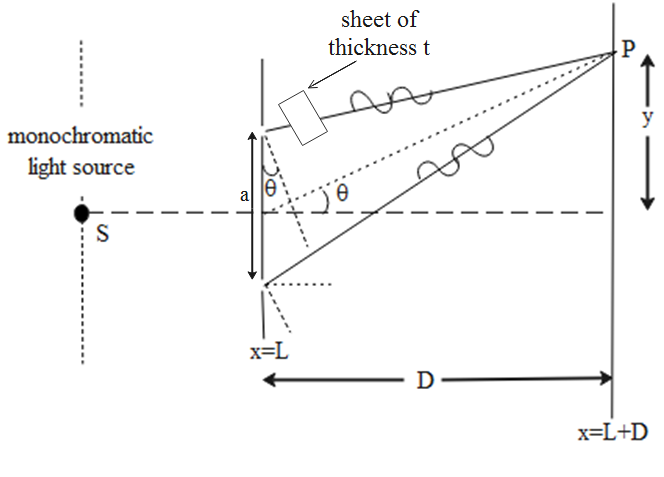

The bright regions in such a diagram represent constructive interference, where the resulting amplitude is large. The dark regions represent destructive interference, where the two contributions cancel partially or almost completely. In the quantum-mechanical interpretation, these regions do not describe deterministic particle trajectories. Instead, they correspond to regions of high and low probability density.

These formulas come from an idealized monochromatic wave model, so they should not be interpreted as exact predictions for every feature of our numerical simulation. Our simulation uses a localized Gaussian wave packet in a finite computational domain, not an infinite plane wave. Nevertheless, the same physical mechanism is present: the wavefunction is split by the barrier, the transmitted parts overlap, and the resulting probability density forms maxima and minima due to superposition.

In the numerical model, the state of the particle is described by a complex-valued wavefunction

$$
\psi(x,y,t),
$$

evolving according to the two-dimensional time-dependent Schrödinger equation. The quantity shown in the animations is the probability density

$$
|\psi(x,y,t)|^2.
$$

This probability density plays a role analogous to the intensity pattern in the optical double-slit experiment. Regions of high probability density correspond to positions where the particle is more likely to be detected, while low-density regions correspond to destructive interference or regions blocked by the potential barrier.

The computational domain is a rectangular two-dimensional grid. In our coordinate convention, the incoming wave packet propagates primarily in the positive $y$-direction. The barrier is placed near $y=0$, while the transverse direction is the $x$-axis. This means that the slit separation is measured along $x$, and the region behind the barrier corresponds to $y>0$. Although the textbook diagram often draws the beam travelling horizontally toward a vertical screen, our numerical setup is equivalent up to a rotation of coordinates.

The incident quantum state is initialized as a Gaussian wave packet. This choice is physically natural because it represents a localized particle-like state while still retaining wave-like properties. The packet has a finite spatial width and a preferred direction of motion determined by its initial momentum. As it evolves, the packet spreads, interacts with the potential barrier, and may be partially transmitted, reflected, diffracted, or tunnelled depending on the form of the potential.

The potential $V(x,y)$ is used to define the experimental obstacle. For the single-slit and double-slit experiments, the barrier is modeled as a very high potential wall with one or two openings. The high-potential regions act as effectively impenetrable parts of the wall, while the openings allow the wavefunction to pass through. In the single-slit case, only one aperture is left open. In the double-slit case, two symmetric apertures are introduced, allowing the transmitted parts of the wavefunction to overlap and interfere.

For the tunnelling experiment, the potential is changed. Instead of an effectively impenetrable wall with openings, we use a finite potential barrier. The barrier height is chosen to be larger than the approximate kinetic energy of the incoming packet. Classically, a particle with energy below the barrier height would be reflected and would not appear on the far side. In quantum mechanics, however, the wavefunction can penetrate into the classically forbidden region and produce a nonzero transmitted component beyond the barrier.

To analyze the simulations, we use several complementary observables. The first is the full two-dimensional probability density $|\psi(x,y,t)|^2$, shown as an animation. This allows us to observe the time evolution of the packet: its approach to the barrier, interaction with the obstacle, and subsequent propagation behind the barrier.

The second observable is a detector-screen profile. Since the packet propagates in the $y$-direction, a numerical screen is represented by a horizontal line at a fixed value $y=y_{\mathrm{screen}}$ behind the barrier. The detector profile is therefore given by

$$
P_{\mathrm{screen}}(x,t) = |\psi(x,y_{\mathrm{screen}},t)|^2.
$$

This one-dimensional slice is useful because it makes the interference fringes easier to identify than in the full two-dimensional animation. In the double-slit case, local maxima in this profile correspond to constructive interference, while local minima correspond to destructive interference.

The third observable is the integrated probability beyond a chosen cutoff line behind the barrier,

$$
T(t) = \int_{y>y_{\mathrm{cut}}} |\psi(x,y,t)|^2 \, dx\, dy.
$$

This quantity is particularly useful in the tunnelling experiment. It measures how much of the wavefunction has entered the region beyond the barrier. If the barrier were truly impenetrable, this quantity would remain zero apart from numerical error. For a finite barrier, however, a nonzero transmitted probability can appear, demonstrating quantum tunnelling.

Thus, the numerical experiment is designed to reproduce the essential elements of Young-type interference while remaining faithful to the Schrödinger description of quantum mechanics. The barrier and slits determine the geometry, the Gaussian packet represents the incoming quantum state, and the probability density provides the observable output. By comparing the single-slit, double-slit, and finite-barrier cases, we can distinguish diffraction, interference, and tunnelling as separate but related consequences of wavefunction evolution.


### Visualization

In [7]:
class Visualizer:
    def __init__(self, grid, V, scenario_name="Quantum Simulation", hard_wall_mask=None, clim_quantile=0.995):
        self.grid = grid
        self.V = V
        self.scenario_name = scenario_name
        self.hard_wall_mask = hard_wall_mask
        self.clim_quantile = clim_quantile

        self.fig, self.ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
        self.cmap = plt.get_cmap("magma")
        self.ax.set_aspect("equal")
        self.ax.set_xlabel("Position x (arb. units)")
        self.ax.set_ylabel("Position y (arb. units)")
        self.ax.set_title(f"2D TDSE: {scenario_name}")

        self.plot_extent = [grid.X.min(), grid.X.max(), grid.Y.min(), grid.Y.max()]

        # Use the physical array orientation directly: rows are y, columns are x.
        potential_overlay = np.ma.masked_where(V <= 0, V)
        self.ax.imshow(
            potential_overlay,
            origin="lower",
            extent=self.plot_extent,
            cmap="Greys",
            alpha=0.65,
            zorder=1,
            interpolation="nearest",
        )

        if hard_wall_mask is not None:
            self.ax.contour(
                grid.X,
                grid.Y,
                hard_wall_mask.astype(float),
                levels=[0.5],
                colors="white",
                linewidths=0.9,
                alpha=0.9,
                zorder=3,
            )

        dummy_data = np.zeros((grid.ny, grid.nx))
        self.img = self.ax.imshow(
            dummy_data,
            origin="lower",
            extent=self.plot_extent,
            cmap=self.cmap,
            zorder=2,
            interpolation="bilinear",
        )
        self.time_text = self.ax.text(
            0.02,
            0.98,
            "t = 0.00",
            transform=self.ax.transAxes,
            ha="left",
            va="top",
            color="white",
            bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none", "pad": 3},
            zorder=4,
        )
        self.fig.colorbar(
            self.img,
            ax=self.ax,
            fraction=0.046,
            pad=0.04,
            label=r"Probability Density $|\psi(x,y,t)|^2$",
        )

    def init_plot(self, psi_0):
        prob_density_0 = np.abs(psi_0)**2
        self.img.set_array(prob_density_0)
        self.img.set_clim(0, max(np.quantile(prob_density_0, self.clim_quantile), 1e-12))
        self.time_text.set_text("t = 0.00")
        return self.img, self.time_text

    def animate(self, psi_t, current_time=0.0):
        prob_density_t = np.abs(psi_t)**2
        self.img.set_array(prob_density_t)
        # Let the scale follow the packet gently as it spreads.
        vmax = max(np.quantile(prob_density_t, self.clim_quantile), 1e-12)
        self.img.set_clim(0, vmax)
        self.time_text.set_text(f"t = {current_time:.2f}")
        return self.img, self.time_text

### Simulation

In [ ]:
SCENARIOS = {
    "double_slit": {
        "title": "Young Double-Slit Interference",
        "potential": {"p_type": "double_slit", "wall_thickness": 0.6, "slit_width": 0.8, "slit_separation": 3.0},
        "packet": {"x0": 0.0, "y0": -9.0, "k0y": 4.5, "sigma": 1.2},
        "hard_wall": True,
        "tracking_y": 0.5,
    },
    "single_slit": {
        "title": "Single-Slit Diffraction Control",
        "potential": {"p_type": "single_slit", "wall_thickness": 0.6, "slit_width": 0.9},
        "packet": {"x0": 0.0, "y0": -9.0, "k0y": 4.5, "sigma": 1.2},
        "hard_wall": True,
        "tracking_y": 0.5,
    },
    "tunneling": {
        "title": "Finite Barrier Quantum Tunneling",
        "potential": {"p_type": "tunneling", "barrier_thickness": 1.0, "barrier_width": 7.0, "V0": 2.4},
        "packet": {"x0": 0.0, "y0": -8.5, "k0y": 2.0, "sigma": 1.6},
        "hard_wall": False,
        "tracking_y": 0.5,
    },
    "free": {
        "title": "Free Gaussian Packet Baseline",
        "potential": {"p_type": "free"},
        "packet": {"x0": 0.0, "y0": -8.5, "k0y": 4.0, "sigma": 1.3},
        "hard_wall": False,
        "tracking_y": 0.5,
    },
}


def run_simulation_and_animate(scenario="double_slit", num_steps=450, dt=0.008, steps_per_frame=2):
    """
    Runs a configured TDSE scenario and returns animation plus transmission data.
    scenario can be: double_slit, single_slit, tunneling, or free.
    """
    config = SCENARIOS.get(scenario, SCENARIOS.get(scenario.lower()))
    if config is None:
        raise ValueError(f"Unknown scenario: {scenario}. Choose from {list(SCENARIOS)}")

    grid = Grid(nx=256, ny=256, dx=0.1, dy=0.1)
    potential_kwargs = config["potential"].copy()
    p_type = potential_kwargs.pop("p_type")
    V0 = potential_kwargs.pop("V0", None)
    V = create_potential(grid, p_type=p_type, V0=V0, **potential_kwargs)

    psi = initialize_wave_packet(grid, **config["packet"])
    hard_wall_mask = V > 1e5 if config["hard_wall"] else None
    propagator = Propagator(grid, V, dt=dt, hard_wall_mask=hard_wall_mask)
    viz = Visualizer(grid, V, config["title"], hard_wall_mask=hard_wall_mask)

    time_steps = []
    transmission_data = []
    current_time = 0.0
    y_cut = config.get("tracking_y", 0.5)

    def update_frame(frame_num):
        nonlocal psi, current_time
        for _ in range(steps_per_frame):
            psi = propagator.step(psi)
            current_time += dt

        if scenario in ("tunneling", "double_slit", "single_slit"):
            time_steps.append(current_time)
            transmission_data.append(calculate_transmission(grid, psi, y_cut=y_cut))

        return viz.animate(psi, current_time)

    anim = animation.FuncAnimation(
        viz.fig,
        update_frame,
        frames=num_steps,
        init_func=lambda: viz.init_plot(psi),
        blit=True,
        interval=20,
    )

    return anim, time_steps, transmission_data, grid, V, psi

def run_simulation_to_time(scenario="double_slit", target_time=3.5, dt=0.008):
    """Evolve a configured TDSE scenario independently up to a fixed target time."""
    config = SCENARIOS.get(scenario, SCENARIOS.get(scenario.lower()))
    if config is None:
        raise ValueError(f"Unknown scenario: {scenario}. Choose from {list(SCENARIOS)}")

    grid = Grid(nx=256, ny=256, dx=0.1, dy=0.1)
    potential_kwargs = config["potential"].copy()
    p_type = potential_kwargs.pop("p_type")
    V0 = potential_kwargs.pop("V0", None)
    V = create_potential(grid, p_type=p_type, V0=V0, **potential_kwargs)

    psi = initialize_wave_packet(grid, **config["packet"])
    hard_wall_mask = V > 1e5 if config["hard_wall"] else None
    propagator = Propagator(grid, V, dt=dt, hard_wall_mask=hard_wall_mask)

    num_steps = int(np.round(target_time / dt))
    actual_time = 0.0
    for _ in range(num_steps):
        psi = propagator.step(psi)
        actual_time += dt

    return grid, V, psi, actual_time


def plot_detector_screen_profile(grid, psi, y_screen=5.0, t=None):
    """Plot |psi|^2 along the grid row closest to the detector-screen y position."""
    y_values = grid.Y[:, 0]
    iy = np.argmin(np.abs(y_values - y_screen))
    x_values = grid.X[iy, :]
    profile = np.abs(psi[iy, :])**2
    y_actual = y_values[iy]

    plt.figure(figsize=(8, 4.5))
    plt.plot(x_values, profile, color="tab:blue", linewidth=2)
    plt.xlabel("x position")
    plt.ylabel(r"Probability density $|\psi(x,y_{\mathrm{screen}},t)|^2$")
    title = "Detector-screen profile for the double slit"
    if t is not None:
        title += f" at t = {t:.3f}"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return x_values, profile, y_actual

def display_animation(anim):
    """Show a JS animation without Jupyter also rendering the final Matplotlib frame."""
    html = HTML(anim.to_jshtml())
    plt.close(anim._fig)
    display(html)

In [ ]:
plt.rcParams["animation.embed_limit"] = 80.0

# Choose: "double_slit", "single_slit", "tunneling", or "free".
my_anim, t_steps, t_data, grid, V, psi_final = run_simulation_and_animate(
    scenario="double_slit",
    num_steps=420,
    dt=0.008,
    steps_per_frame=2,
)

display_animation(my_anim)

if t_data:
    plt.figure(figsize=(8, 4.5))
    plt.plot(t_steps, t_data, color="tab:blue", linewidth=2)
    plt.title("Probability beyond the barrier/slits")
    plt.xlabel("Time (arb. units)")
    plt.ylabel("Integrated probability")
    plt.grid(True, alpha=0.3)
    plt.show()

### Detector-Screen Profile

To make the interference pattern more visible, we extract a one-dimensional slice of the probability density behind the barrier. The numerical detector screen is represented by a horizontal line at a fixed value $y=y_{\mathrm{screen}}$. Along this line, we plot

$$
P_{\mathrm{screen}}(x,t)=|\psi(x,y_{\mathrm{screen}},t)|^2.
$$

Local maxima in this profile correspond to constructive interference, while local minima correspond to destructive interference.

In [ ]:
grid_screen, V_screen, psi_screen, t_screen = run_simulation_to_time(
    scenario="double_slit",
    target_time=3.5,
    dt=0.008,
)

plot_detector_screen_profile(
    grid_screen,
    psi_screen,
    y_screen=5.0,
    t=t_screen,
);

### References

**Textbooks (general background — duality, Schrödinger equation, wave packets, tunneling):**

1. D. J. Griffiths and D. F. Schroeter, *Introduction to Quantum Mechanics*, 3rd ed., Cambridge University Press, 2018. — Motivation of the TDSE (Ch. 1–2), free-particle wave packets and group velocity (§2.4), the finite barrier and tunneling (§2.6).
2. J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed., Cambridge University Press, 2021. — Operator formalism, the Hamiltonian as generator of time evolution, unitarity.
3. D. J. Tannor, *Introduction to Quantum Mechanics: A Time-Dependent Perspective*, University Science Books, 2007. — Wave-packet dynamics and the split-operator / Fourier propagation method used in this project.
4. R. P. Feynman, R. B. Leighton, and M. Sands, *The Feynman Lectures on Physics, Vol. III: Quantum Mechanics*, Ch. 1, Addison-Wesley, 1965. — The double-slit experiment as the central illustration of quantum behaviour. (Online: https://www.feynmanlectures.caltech.edu/III_01.html)

**Primary historical sources (wave–particle duality):**

5. A. Einstein, "Über einen die Erzeugung und Verwandlung des Lichtes betreffenden heuristischen Gesichtspunkt," *Annalen der Physik* **17** (1905) 132–148. DOI: 10.1002/andp.19053220607. — Light quanta (photons); $E=h\nu$.
6. L. de Broglie, *Recherches sur la théorie des quanta*, doctoral thesis, University of Paris, 1924. — Matter waves; $\lambda = h/p$.
7. M. Born, "Zur Quantenmechanik der Stoßvorgänge," *Zeitschrift für Physik* **37** (1926) 863–867. DOI: 10.1007/BF01397477. — The probabilistic (Born) interpretation of $|\psi|^2$.
8. C. Davisson and L. H. Germer, "Diffraction of Electrons by a Crystal of Nickel," *Physical Review* **30** (1927) 705–740. DOI: 10.1103/PhysRev.30.705. — Experimental confirmation of matter waves.

**Numerical method (SOFT / split-operator):**

9. M. D. Feit, J. A. Fleck Jr., and A. Steiger, "Solution of the Schrödinger equation by a spectral method," *Journal of Computational Physics* **47** (3) (1982) 412–433. DOI: 10.1016/0021-9991(82)90091-2. — The split-operator Fourier method for propagating the TDSE.
10. G. Strang, "On the Construction and Comparison of Difference Schemes," *SIAM Journal on Numerical Analysis* **5** (3) (1968) 506–517. DOI: 10.1137/0705041. — Second-order operator (Strang) splitting.